## Test creating a transformer to analyse lensing images

Initial plan:

* Tokenise images with small patch size (3x3?)
* Simplest possible transformer with generic MLP
* Test layer number, size
* Test token patch size
* Test transformer size/structure
* Test ensemble performance

#### Stretch goal options

* More specific NN types or structures (ViT? CNN?)

In [19]:
import glob
import math
import time
import os
from itertools import cycle

import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data_util
import torchvision
from matplotlib import pyplot as plt
from numpy import interp
from sklearn.preprocessing import label_binarize
%matplotlib inline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc
import torch_optimizer as optim


### Extract patch information

Cut the image into non-overlapping patch_size x patch_size squares and projects each patch into a `dim`-vector token.

The dimensionality is the size of the vector that accumulates information between patches.

In [20]:
class PatchEmbed(nn.Module):

    def __init__(self: PatchEmbed,
                 patch_size: int,
                 dim: int, # this is the size of the vector that accumulates information - unrelated to the image size
                 img_size: int,
                 in_ch: int):
        super().__init__()
        # I can't believe you can just dynamically assign an untyped property and it's public!
        self.n_tokens = (img_size // patch_size) ** 2

        # Actually important to set as a property, python breaks if not :(
        self.conv2d = nn.Conv2d(
                in_ch,
                dim,
                kernel_size = patch_size,
                stride = patch_size)

    def forward(self, x):
        # applies a convolutional layer and reshapes it to a token
        return (self
                .conv2d(x)
                .flatten(2)
                .transpose(1, 2))

### Attention class

Multi-head self-attention: every token looks at every other token and mixes in a weighted sum of their values.

Black magic

#### Step 1

`.calculate_qkv(x)`: make q, k, v in one matmul

x:   (batch_size, n_tokens, dim)      = (256, 65, 64)
out: (batch_size, n_tokens, dim*3)    = (256, 65, 192)

self.qkv is a single Linear(64, 192). Rather than three separate layers, it produces the query, key, and value for every token in one matrix multiply — that's why the output width is dim*3 = 192. Those 192 numbers per token are the three dim-vectors concatenated.

#### Step 2

`.reshape(..., 3, heads, dim // heads)`: carve up that flat 192

(256, 65, 192)  ->  (256, 65, 3, 4, 16)

Pure reinterpretation of the last axis — no data moves. The flat 192 is split into 3 × 4 × 16:
- 3 — which of {query, key, value}
- heads = 4 — which attention head
- dim // heads = 16 — that head's slice of the vector (head_dim)

Splitting dim across heads is what makes it multi-head: each head gets its own 16-D subspace to compute attention in, so different heads can specialize (e.g. one tracks nearby patches, another tracks the far arc).

Reshape assumes the Linear laid its 192 outputs out in exactly this qkv → head → head_dim order.

#### Step 3

`.permute(2, 0, 3, 1, 4)`: reorder the axes for the matmul

permute reorders axes by their indices. Current axes are [0:batch, 1:tokens, 2:qkv, 3:heads, 4:head_dim]. The argument (2, 0, 3, 1, 4) means "new axis order = old [2, 0, 3, 1, 4]":

| new axis | comes from | meaning | size |
| --- | --- | --- | --- |
| 0 | old 2 | qkv | 3 |
| 1 | old 0 | batch | 256 |
| 2 | old 3 | heads | 4 |
| 3 | old 1 | tokens | 65 |
| 4 | old 4 | head_dim | 16 |

(256, 65, 3, 4, 16)  ->  (3, 256, 4, 65, 16)

Two reasons for this exact order:

1. qkv (the 3) goes to the front so the next line can peel them apart by indexing: q, k, v = qkv[0], qkv[1], qkv[2]. Each comes out as (batch, heads, n_tokens, head_dim) = (256, 4, 65, 16).
2. batch and heads become the two leading axes, leaving (n_tokens, head_dim) as the trailing 2-D matrix. That lets the attention step q @ k.transpose(-2, -1) run as a batched matmul: it produces an (n_tokens, n_tokens) = 65×65 score matrix independently for each of the 256 × 4 = 1024 (image, head) pairs, all in parallel on the GPU.

Net effect of the chain: (B, N, dim) → (3, B, heads, N, head_dim) — from "one vector per token" to "separated q/k/v, per head, per image, ready for parallel attention."

In [21]:

class Attention(nn.Module):
    def __init__(self,
                 dim: int,
                 heads: int = 4):
        super().__init__()
        self.dim = dim
        self.heads = heads
        self.scale = (dim // heads) ** -0.5

        # create once, likely for for performance
        self.calculate_qkv = nn.Linear(dim, dim * 3) # query, key and value!
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        b_size, n_tokens, dim = x.shape
        qkv = (self
            .calculate_qkv(x)
            .reshape(b_size, n_tokens, 3, self.heads, dim // self.heads)
            .permute(2, 0, 3, 1, 4))

        # each (batch size, heads, N, head_dim)
        query, key, value = qkv[0], qkv[1], qkv[2]

        # @ = matmul
        # (B, heads, N, N) similarity scores
        attn = (query @ key.transpose(-2, -1)) * self.scale

        attn = attn.softmax(dim=-1) # vector summed to 1

        out = ((attn @ value)
               .transpose(1, 2)
               .reshape(b_size, n_tokens, dim))

        return self.proj(out)


### Block class

One transformer encoder block, pre-norm style:
        x = x + Attention(LayerNorm(x))     <- tokens exchange information
        x = x + MLP(LayerNorm(x))           <- each token is processed on its own
    The residual (+ x) is what lets you stack many blocks without the signal vanishing.


In [22]:

class Block(nn.Module):
    def __init__(self,
                 dim: int,
                 heads: int,
                 mlp_ratio: float,
                 dropout: float):
        super().__init__()

        self.attn = Attention(dim, heads)
        self.norm1 = nn.LayerNorm(dim)

        hidden_layer_width = int(dim * mlp_ratio)

        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_layer_width),
            nn.GELU(approximate="none"), # can be tanh
            nn.Dropout(dropout),
            nn.Linear(hidden_layer_width, dim))

        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


### Vision transformer model

Use the classes together to do more magic


    The whole Vision Transformer, ~5 conceptual lines:
        calculate patches
        -> prepend a learnable CLS token
        -> add position embeddings
        -> N transformer blocks
        -> read out the CLS token
        -> classify.

In [23]:

class MinimalViT(nn.Module):
    def __init__(self,
                 img_size: int = 64,
                 patch_size: int = 8,
                 in_ch: int = 1,
                 dim: int = 64,
                 depth: int = 4,
                 heads: int = 4,
                 n_classes: int = 3,
                 dropout: float = 0.1):
        super().__init__()

        self.patch = PatchEmbed(patch_size, dim, img_size, in_ch)
        n_tkns = self.patch.n_tokens

        # Classification is the output slot
        # Attention gets a global view of the image and we classify from it
        self.classification = nn.Parameter(torch.zeros(1, 1, dim))

        # Ration of dim to mlp layer size
        # 1 and 3 both reduce accuracy
        mlp_ratio: float = 2.0

        # Position embeddings
        self.pos = nn.Parameter(torch.zeros(1, n_tkns + 1, dim))
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList( #  * (i / depth)
            [Block(dim, heads, mlp_ratio, dropout) for i in range(depth)]
        )

        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, n_classes)

        nn.init.trunc_normal_(self.pos, std=0.02)
        nn.init.trunc_normal_(self.classification, std=0.02)

    def forward(self, x):
        b_size = x.shape[0]
        x = self.patch(x) # (batch size, 64, dim)
        cls = self.classification.expand(b_size, -1, -1) # (batch size, 1, dim)
        x = torch.cat([cls, x], dim=1) + self.pos # (batch size, 65, dim)
        x = self.drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)

        return self.head(x[:, 0]) # classify from the CLS token


def warmup_cosine(step, total_steps, warmup_frac=0.1):
    """
    LR multiplier: linearly warm up, then cosine-decay to 0.
    This is the transformer schedule. Warmup matters a lot
    for from-scratch ViTs: the attention weights are random
    at the start, so a few gentle steps stop the model diverging.
    """
    warmup = int(total_steps * warmup_frac)
    if step < warmup:
        return step / max(1, warmup)
    progress = (step - warmup) / max(1, total_steps - warmup)
    return 0.5 * (1 + math.cos(math.pi * progress))

### Load data

Copied from example

Samples with no substructure: 


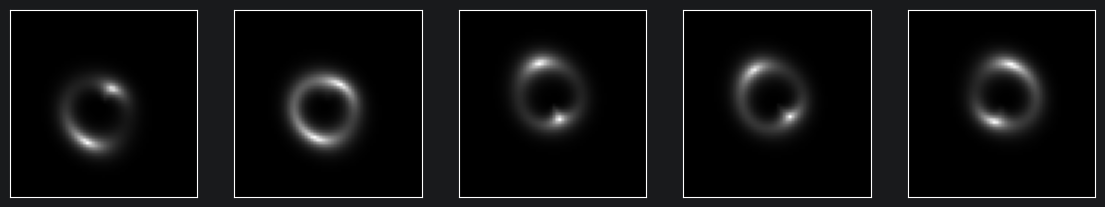

Samples with spherical substructure: 


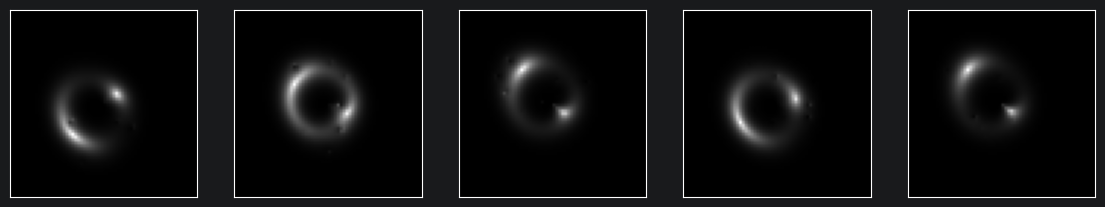

Samples with vortex substructure: 
Training Classes: {'axion': 0, 'cdm': 1, 'no': 2}
Validation Classes: {'axion': 0, 'cdm': 1, 'no': 2}


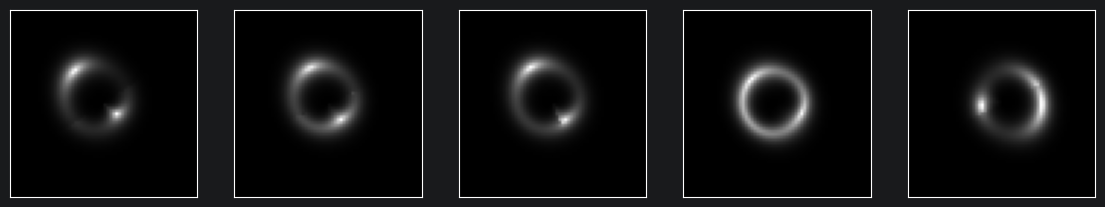

In [24]:
# Load data

# Set Batch Size
batch_size = 100

# Model params for this run
patch_size = 4
depth = 8

# Define a function to load .npy files
def npy_loader(path):
    sample = torch.from_numpy(np.load(path))  # Load the numpy file and convert it to a torch tensor
    return sample

# Define the input paths
train_path1 = './GravitationalLensingChallenge/dataset/train/no'
train_files1 = [os.path.join(train_path1, f) for f in os.listdir(train_path1) if f.endswith(".npy")]
train_path2 = './GravitationalLensingChallenge/dataset/train/cdm'
train_files2 = [os.path.join(train_path2, f) for f in os.listdir(train_path2) if f.endswith(".npy")]
train_path3 = './GravitationalLensingChallenge/dataset/train/axion'
train_files3 = [os.path.join(train_path3, f) for f in os.listdir(train_path3) if f.endswith(".npy")]

# Number of samples to display per class
n = 5

# Plot the samples with no substructure
i = 1
print('Samples with no substructure: ')
plt.rcParams['figure.figsize'] = [14, 14]  # Set the figure size
for image in train_files1[:n]:
    ax = plt.subplot(3, n, i)  # Create subplot
    plt.imshow(np.load(image).reshape(64, 64), cmap='gray')  # Load and display the image
    ax.get_xaxis().set_visible(False)  # Hide x-axis
    ax.get_yaxis().set_visible(False)  # Hide y-axis
    i += 1
plt.show()  # Show the plot

# Plot the samples with spherical substructure
print('Samples with spherical substructure: ')
plt.rcParams['figure.figsize'] = [14, 14]  # Set the figure size
for image in train_files2[:n]:
    ax = plt.subplot(3, n, i)  # Create subplot
    plt.imshow(np.load(image).reshape(64, 64), cmap='gray')  # Load and display the image
    ax.get_xaxis().set_visible(False)  # Hide x-axis
    ax.get_yaxis().set_visible(False)  # Hide y-axis
    i += 1
plt.show()  # Show the plot

# Plot the samples with vortex substructure
print('Samples with vortex substructure: ')
plt.rcParams['figure.figsize'] = [14, 14]  # Set the figure size
for image in train_files3[:n]:
    ax = plt.subplot(3, n, i)  # Create subplot
    plt.imshow(np.load(image).reshape(64, 64), cmap='gray')  # Load and display the image
    ax.get_xaxis().set_visible(False)  # Hide x-axis
    ax.get_yaxis().set_visible(False)  # Hide y-axis
    i += 1

# Load training data
train_data = torchvision.datasets.DatasetFolder(
    root='./GravitationalLensingChallenge/dataset/train',
    loader=npy_loader,
    extensions='.npy'
)
print("Training Classes: " + str(train_data.class_to_idx))  # Print the classes found in the training data
train_data_loader = data_util.DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)  # Create a data loader for training data

# Load validation data
val_data = torchvision.datasets.DatasetFolder(
    root='./GravitationalLensingChallenge/dataset/val',
    loader=npy_loader,
    extensions='.npy'
)

print("Validation Classes: " + str(val_data.class_to_idx))  # Print the classes found in the validation data

# Create a data loader for validation data
val_data_loader = data_util.DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

### Training loop

In [25]:

# LR Scaling should be sr batch size

# Loss Function
criteria = nn.CrossEntropyLoss()



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MinimalViT(
    patch_size=patch_size,
    depth=depth,
).to(device)

# Set the number of training epochs
n_epochs = 500

# Optimizer

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-3,
    weight_decay=1e-2)

# Shampoo is inappropriate - moves processing to CPU (~10x longer and reduces accuracy
# optimizer = optim.Shampoo(model.parameters(), lr=0.01)

# Calculate the number of batches for training data
n_batches_train = (len(train_files1) * 3) / batch_size  # Equal number of files in each class

patience = 6
epochs_no_improv = 0
best_acc = 0
best_model = None
# Progress bar for epochs
# pbar = tqdm(range(1, n_epochs + 1))
for epoch in range(1, n_epochs + 1):
    train_loss = 0.0
    train_acc = 0.0

    # Iterate over the training data loader
    for step, (x_tr, y_tr) in enumerate(train_data_loader):
        data = x_tr.to(device).float()  # Move input data to the device and convert to float
        labels = y_tr.to(device, dtype=torch.long)  # Move labels to the device and convert to long
        optimizer.zero_grad()  # Clear the gradients
        outputs = model(data)  # Forward pass through the model
        _, preds = torch.max(outputs.data, 1)  # Get the predictions
        correct = (preds == labels).float().sum()  # Calculate the number of correct predictions
        optimizer.zero_grad()
        loss = criteria(outputs, labels)  # Calculate the loss
        loss.backward()  # Backpropagation
        optimizer.step()

        train_loss += loss.item()  # Accumulate the loss
        train_acc += correct.item() / data.shape[0]  # Accumulate the accuracy


    # Calculate the average loss and accuracy for the epoch
    train_loss = train_loss / n_batches_train
    train_acc = train_acc / n_batches_train

    print(f"epoch: {epoch}, loss: {train_loss:3f}, acc: {train_acc:3f}")

    if train_acc < best_acc:
        epochs_no_improv += 1
    else:
        epochs_no_improv = 0
        best_acc = train_acc
        best_model = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epochs_no_improv >= patience:
        print(f"no improvement for {patience} epochs, finishing")
        break

    # Display the training statistics
    # pbar.set_postfix({'Training Loss': train_loss, 'Training Acc': train_acc})
state = {k.replace("_orig_mod.", ""): v for k, v in best_model.items()}
torch.save(state, os.path.join("./GravitationalLensingChallenge", "best-model.pt"))

epoch: 1, loss: 1.109416, acc: 0.331700
epoch: 2, loss: 1.101604, acc: 0.335367
epoch: 3, loss: 1.059057, acc: 0.395900
epoch: 4, loss: 0.797680, acc: 0.591433
epoch: 5, loss: 0.656312, acc: 0.688400
epoch: 6, loss: 0.564205, acc: 0.748233
epoch: 7, loss: 0.515549, acc: 0.772733
epoch: 8, loss: 0.477667, acc: 0.792933
epoch: 9, loss: 0.467512, acc: 0.797500
epoch: 10, loss: 0.450166, acc: 0.810433
epoch: 11, loss: 0.443564, acc: 0.810733
epoch: 12, loss: 0.424151, acc: 0.820767
epoch: 13, loss: 0.420390, acc: 0.823767
epoch: 14, loss: 0.404701, acc: 0.829633
epoch: 15, loss: 0.400640, acc: 0.830200
epoch: 16, loss: 0.386847, acc: 0.838200
epoch: 17, loss: 0.392002, acc: 0.836400
epoch: 18, loss: 0.381807, acc: 0.840633
epoch: 19, loss: 0.389785, acc: 0.836400
epoch: 20, loss: 0.378422, acc: 0.840233
epoch: 21, loss: 0.364134, acc: 0.847700
epoch: 22, loss: 0.364327, acc: 0.847633
epoch: 23, loss: 0.358897, acc: 0.850033
epoch: 24, loss: 0.352741, acc: 0.851433
epoch: 25, loss: 0.351374

### Testing

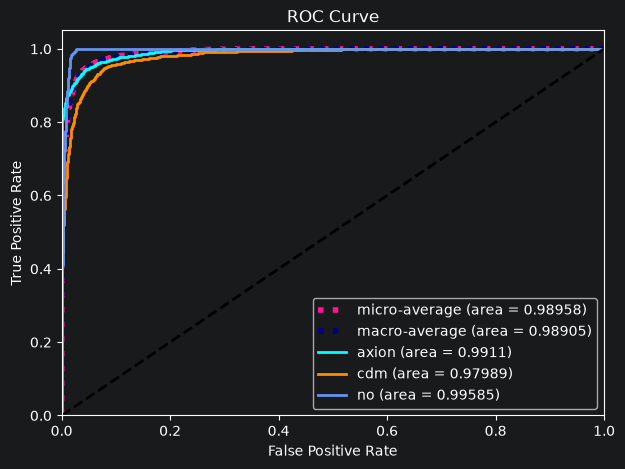

In [26]:
# initialize lists to store scores and labels
y_score = []
y_test = []

# I really wish i could do if (device == null) like a normal language
device = globals().get("device") or torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = globals().get("model")
if model is None:
    model = MinimalViT(
        patch_size=patch_size,
        depth=depth
    ).to(device)

model.load_state_dict(
    torch.load("./GravitationalLensingChallenge/best-model.pt", map_location=device)
)

# ensure dropout isn't used
model.eval()
# Iterate over the validation data loader
for _, (x_ts, y_ts) in enumerate(val_data_loader):
    mini_val_data = x_ts.to(device).float()  # Move validation data to the device and convert to float
    y_ts = y_ts.to(device, dtype=torch.long)  # Move labels to the device and convert to long

    with torch.no_grad():  # Disable gradient calculation for validation
        outputs = model(mini_val_data)  # Forward pass through the model
        probabilities = torch.nn.functional.softmax(outputs, dim=1)  # Apply softmax to get probabilities

    # Append the probabilities and labels to the respective lists
    y_score.append(probabilities.cpu().detach().numpy())
    y_test.append(y_ts.cpu().detach().numpy())

# Convert the lists to numpy arrays and reshape them
y_score = np.asarray(y_score).reshape(-1, 3)
y_val = np.asarray(y_test).reshape(-1)

# Binarize the labels for multi-class evaluation
y_val = label_binarize(y_val, classes=[0, 1, 2])

# Number of classes
n_classes = y_val.shape[1]

# Initialize dictionaries to store false positive rates (fpr), true positive rates (tpr), and ROC AUC values
fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC curve and ROC area for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_val.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Initialize mean true positive rate (tpr)
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Average it and compute macro-average ROC curve and ROC area
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plotting the ROC curves
plt.rcParams['figure.figsize'] = [7, 5]  # Set figure size
lw = 2  # Line width
plt.figure()

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average (area = {})'
               ''.format(round(roc_auc["micro"], 5)),
         color='deeppink', linestyle=':', linewidth=4)

# Plot macro-average ROC curve
plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average (area = {})'
               ''.format(round(roc_auc["macro"], 5)),
         color='navy', linestyle=':', linewidth=4)

# Plot ROC curves for each class
labels = ['axion', 'cdm', 'no']
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='{} (area = {})'
             ''.format(labels[i], round(roc_auc[i], 5)))

# Plot the diagonal line (chance level)
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right", prop={"size": 10})  # Add legend
plt.show()  # Display the plot